
📊 DATA PREVIEW:

   video_id    title  views  likes  comments  watch_time_minutes  \
0         1  Video 1  75205   6181      3335               77806   
1         2  Video 2  95299  12025      3576               33328   
2         3  Video 3  98779  16189      3765              103697   
3         4  Video 4  24351   2952       698               14204   
4         5  Video 5  33282   4669       512               25333   

   subscribers_gained upload_day  
0                6711   Saturday  
1                6660   Thursday  
2                6091   Saturday  
3                2290     Monday  
4                1246     Sunday  

Missing Values:
 video_id              0
title                 0
views                 0
likes                 0
comments              0
watch_time_minutes    0
subscribers_gained    0
upload_day            0
dtype: int64

📈 BASIC STATISTICS:

          video_id         views        likes     comments  \
count  1000.000000   1000.000000   1000.00000  1000.0000

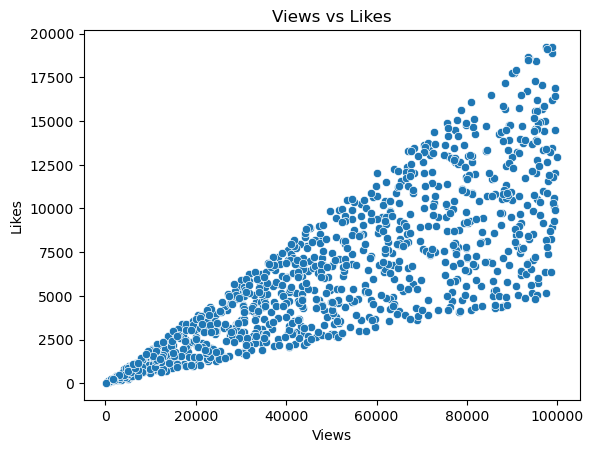

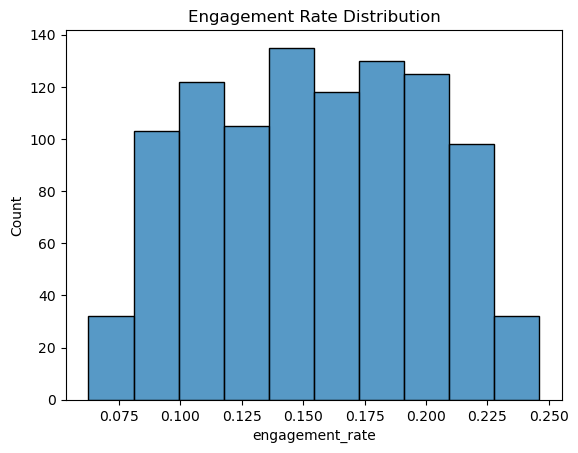


🤖 MODEL PERFORMANCE:
Mean Absolute Error: 5518.2692663804755

📌 SAMPLE PREDICTION:
Predicted Views: 87638

💡 INSIGHTS:
Average Engagement Rate: 0.15
Best Upload Day (approx): upload_day_Saturday

✅ Analysis Complete!


In [1]:
# ==========================================
# YOUTUBE CHANNEL ANALYZER & VIEWER INSIGHTS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# -------------------------------
# 1. LOAD DATASET
# -------------------------------
data = pd.read_csv("youtube_data_1000.csv")

print("\n📊 DATA PREVIEW:\n")
print(data.head())

# -------------------------------
# 2. DATA CLEANING
# -------------------------------
# Check missing values
print("\nMissing Values:\n", data.isnull().sum())

# Fill missing values (if any)
data.fillna(0, inplace=True)

# -------------------------------
# 3. FEATURE ENGINEERING
# -------------------------------
# Engagement Rate = (likes + comments) / views
data['engagement_rate'] = (data['likes'] + data['comments']) / data['views']

# Convert upload_day to numeric
data = pd.get_dummies(data, columns=['upload_day'], drop_first=True)

# -------------------------------
# 4. DATA ANALYSIS
# -------------------------------
print("\n📈 BASIC STATISTICS:\n")
print(data.describe())

# Top performing videos
top_videos = data.sort_values(by='views', ascending=False).head(3)
print("\n🔥 TOP VIDEOS:\n")
print(top_videos[['title', 'views', 'likes']])

# -------------------------------
# 5. VISUALIZATION
# -------------------------------

# Views vs Likes
plt.figure()
sns.scatterplot(x=data['views'], y=data['likes'])
plt.title("Views vs Likes")
plt.xlabel("Views")
plt.ylabel("Likes")
plt.show()

# Engagement Rate Distribution
plt.figure()
sns.histplot(data['engagement_rate'], bins=10)
plt.title("Engagement Rate Distribution")
plt.show()

# -------------------------------
# 6. MACHINE LEARNING MODEL
# -------------------------------
# Predict Views

features = data.drop(columns=['views', 'title', 'video_id'])
target = data['views']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation
error = mean_absolute_error(y_test, predictions)

print("\n🤖 MODEL PERFORMANCE:")
print("Mean Absolute Error:", error)

# -------------------------------
# 7. SAMPLE PREDICTION
# -------------------------------
sample = X_test.iloc[0:1]
predicted_views = model.predict(sample)

print("\n📌 SAMPLE PREDICTION:")
print("Predicted Views:", int(predicted_views[0]))

# -------------------------------
# 8. INSIGHTS
# -------------------------------
print("\n💡 INSIGHTS:")

avg_engagement = data['engagement_rate'].mean()
print(f"Average Engagement Rate: {avg_engagement:.2f}")

best_day = data.groupby(data.filter(like='upload_day').idxmax(axis=1))['views'].mean().idxmax()
print("Best Upload Day (approx):", best_day)

print("\n✅ Analysis Complete!")